## Feature importance and model explainability

#### Install SHAP

#### Import packages

In [5]:
import pandas as pd
import numpy as np
import shap

from xgboost import XGBClassifier

import matplotlib.pyplot as plt


#### Load the engineered dataset

In [6]:
data = pd.read_parquet(
    "../data/processed/train_transaction_features.parquet",
    engine="fastparquet"
)

print(f"Data shape: {data.shape}")

Data shape: (590540, 359)


#### Prepare features and target

In [7]:
y = data["isFraud"]

X = data.drop(columns=["isFraud", "TransactionID"])
X = X.select_dtypes(include=["number"])

print(f"Features count: {X.shape[1]}")

Features count: 343


#### Create the chronological split

In [8]:
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_validation = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_validation = y.iloc[split_index:]

print("Training rows: ", len(X_train))
print("Validation rows: ", len(X_validation))

Training rows:  472432
Validation rows:  118108


#### Calculate class weight

In [9]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Scale pos weight: ", scale_pos_weight)

Scale pos weight:  27.46147358274595


#### Train the best model again

In [10]:
# Best model found in 09_xgboost_hyperparameter_tuning
best_model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

best_model.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


### Part A: XGBoost feature importance

#### Extract feature importance

In [11]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance", 
    ascending=False
)

feature_importance.head(20)

,feature,importance
259,V258,0.149912
295,V294,0.058940
100,V70,0.054404
121,V91,0.045460
219,V218,0.033628
202,V201,0.024987
258,V257,0.017345
22,C14,0.014249
16,C8,0.012776
64,V34,0.009690


#### Plot the top 20 features

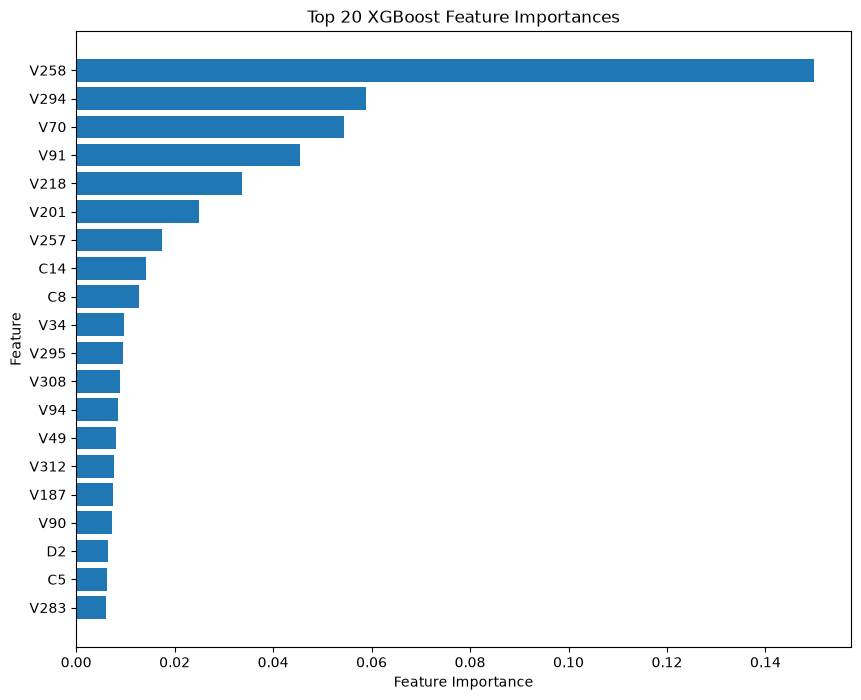

In [12]:
top_features = feature_importance.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 XGBoost Feature Importances")

plt.show()

## SHAP explanations

#### Create a smaller SHAP sample

In [13]:
shap_sample = X_validation.sample(
    n=5000,
    random_state=42
)

print(f"SHAP sample shape: {shap_sample.shape}")

SHAP sample shape: (5000, 343)


#### Create SHAP explainer

In [14]:
# Tree Explainer is optimized for tree-based models like XGBoost
explainer = shap.TreeExplainer(best_model)

#### Calculate SHAP values

In [18]:
# Calculate how much each feature contributes to the prediction in the sample
shap_values = explainer(shap_sample)

#### Global SHAP importance plot

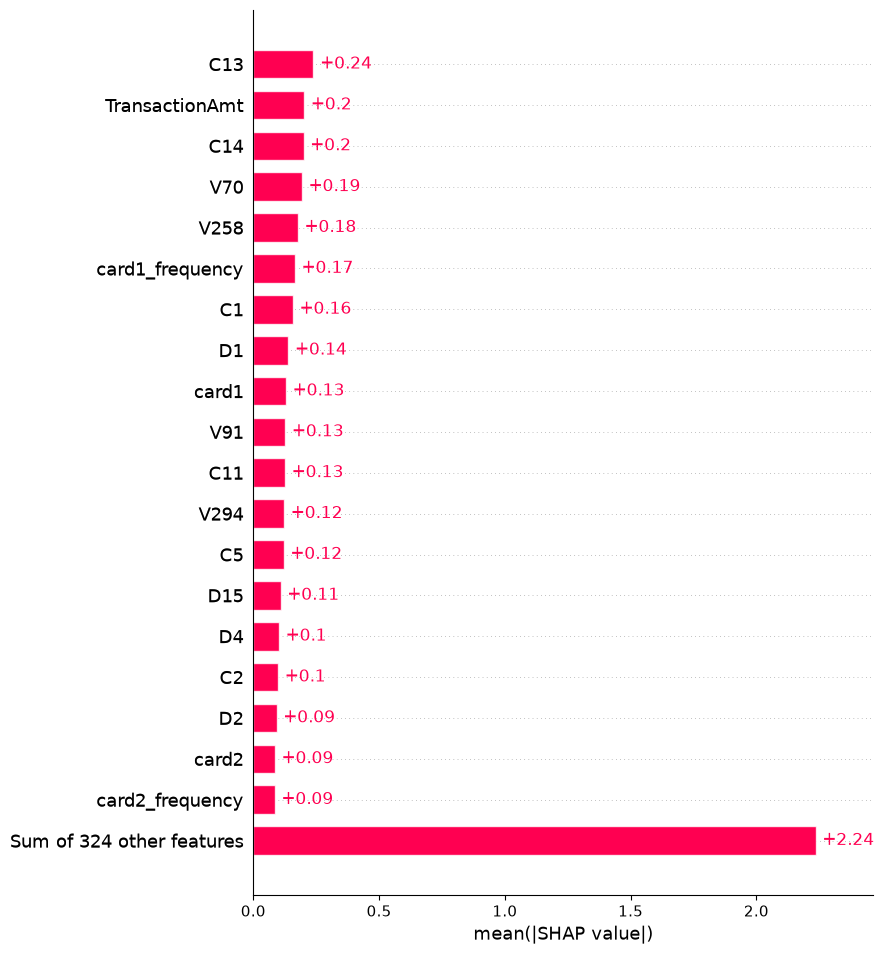

In [19]:
shap.plots.bar(
    shap_values,
    max_display=20
)

#### SHAP beeswarm plot

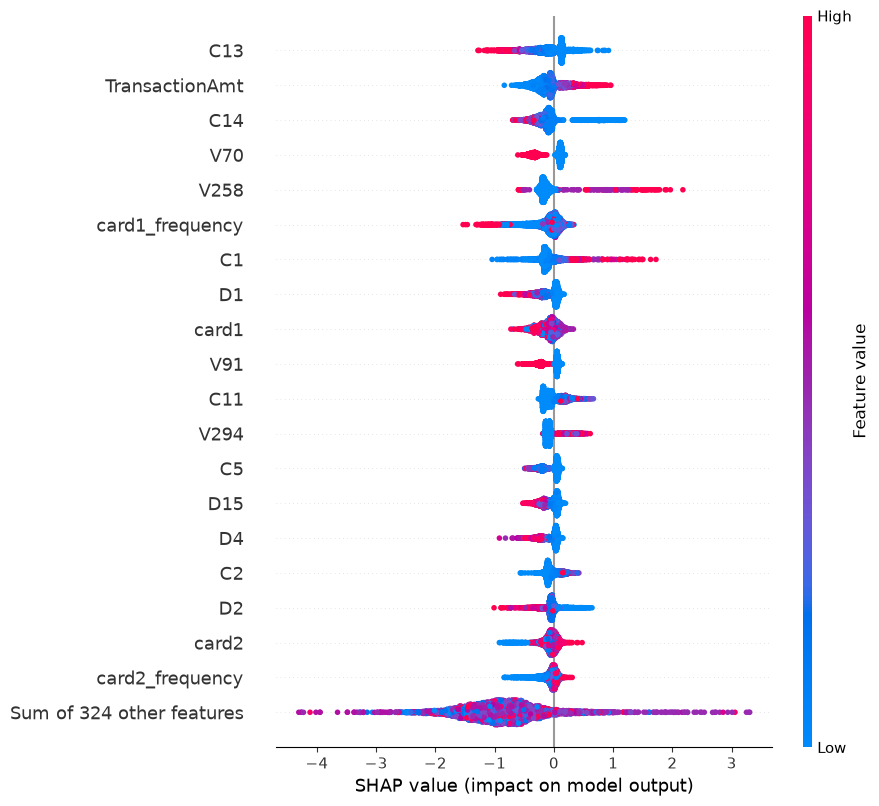

In [20]:
shap.plots.beeswarm(
    shap_values,
    max_display=20
)

## Part C: Explain one suspicious transaction

#### Find a high-risk transaction

In [28]:
# Get fraud probabilities for validation data
fraud_probabilities = best_model.predict_proba(X_validation)[:,1]

# Create a DF so probabilities are easy to analyze
prediction_results = pd.DataFrame({
    "fraud_probability": fraud_probabilities
}, index=X_validation.index)

# Sort from highest predicted fraud risk to lowest
prediction_results = prediction_results.sort_values(
    by="fraud_probability",
    ascending=False
)

prediction_results.head(10)

,fraud_probability
533645,0.999632
535631,0.999515
485050,0.999472
510974,0.999448
558324,0.999406
535630,0.999396
553439,0.999392
553441,0.999382
494067,0.999275
481444,0.999248


#### Check whether the top-risk predictions were actually fraud

In [37]:
prediction_results["actual_isFraud"] = y_validation
prediction_results.head(10)

,fraud_probability,actual_isFraud
533645,0.999632,1
535631,0.999515,1
485050,0.999472,1
510974,0.999448,1
558324,0.999406,1
535630,0.999396,1
553439,0.999392,1
553441,0.999382,1
494067,0.999275,1
481444,0.999248,1


#### Check what percentage of the top 100 highest-risk transaction were actually fraudulent

In [38]:
top_100_precision = (
    prediction_results.head(100)["actual_isFraud"].mean()
)

print(f"Fraud rate in top 100 predictions: {top_100_precision:.2%}")

Fraud rate in top 100 predictions: 92.00%


#### Select the highest-risk transaction

In [30]:
# Get the original index of the highest-risk transaction
high_risk_index = prediction_results.index[0]

# Select that transaction as a one-row DF
high_risk_transaction = X_validation.loc[[high_risk_index]]

high_risk_transaction

,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,dist1,C1,...,card5_frequency,P_emaildomain_is_gmail,P_emaildomain_is_yahoo,P_emaildomain_is_hotmail,P_emaildomain_is_outlook,R_emaildomain_is_gmail,R_emaildomain_is_yahoo,R_emaildomain_is_hotmail,R_emaildomain_is_outlook,addr_match
533645,14061752,73.776,5812,408.0,185.0,224.0,299.0,87.0,8.0,330.0,...,81513,1,0,0,0,1,0,0,0,0


#### Generate SHAP explanation for that transaction

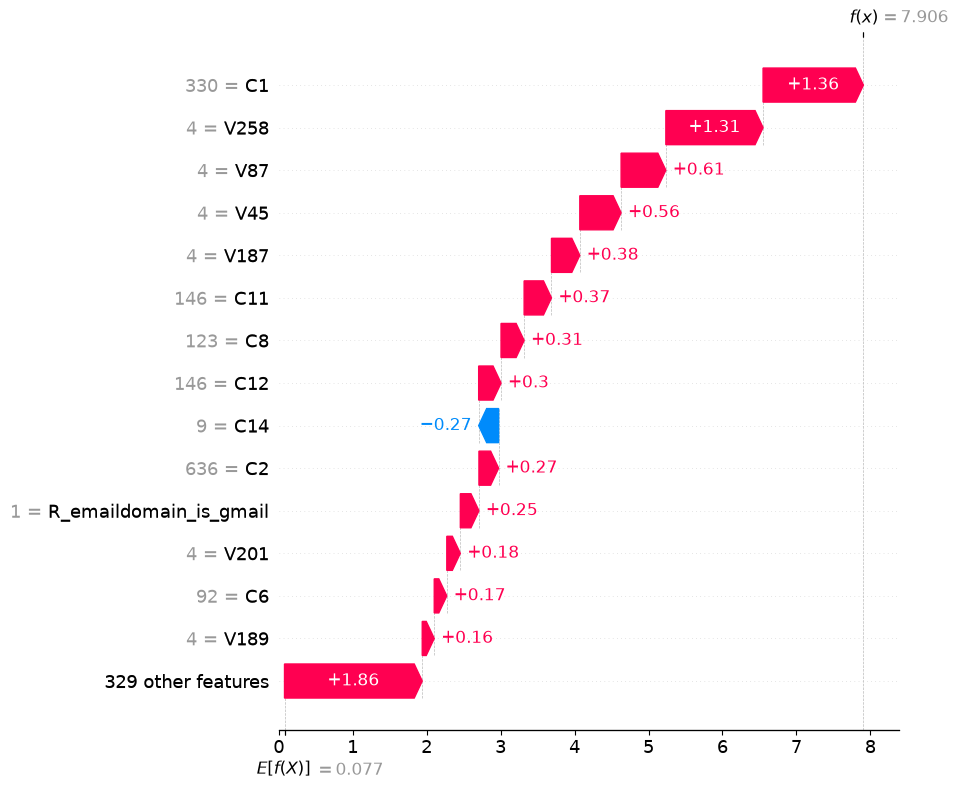

In [31]:
# Calculate SHAP values for the selected transaction
high_risk_shap = explainer(
    high_risk_transaction
)

# Waterfall plot shows exactly how features built up the prediction
shap.plots.waterfall(
    high_risk_shap[0],
    max_display=15
)

#### Compare with a low-risk transaction

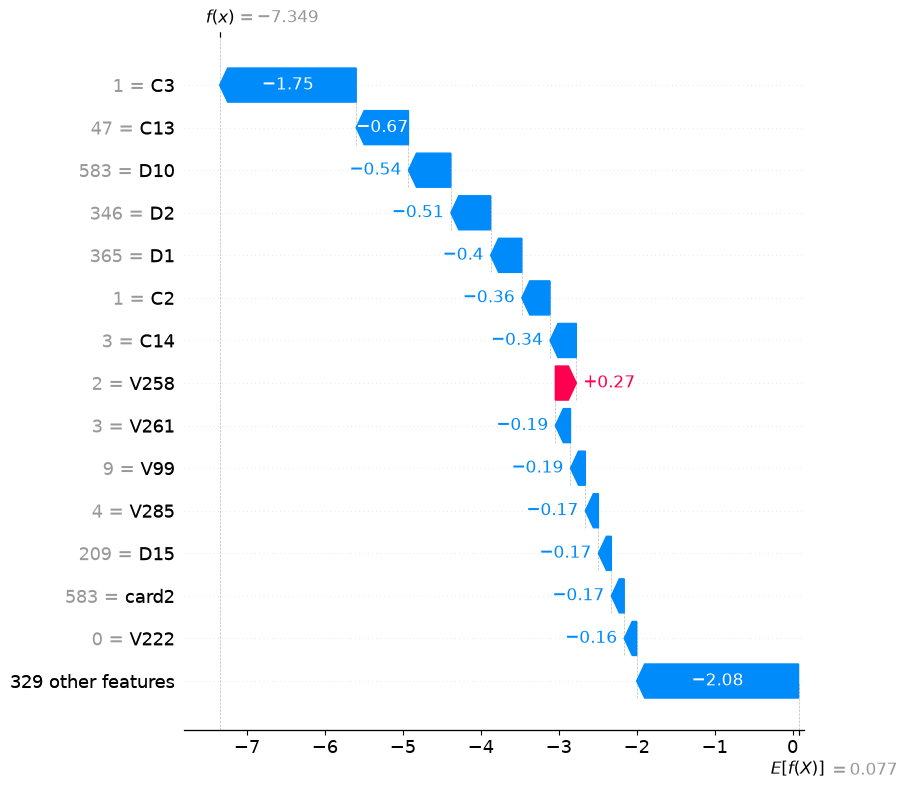

In [33]:
# Select the transaction with lowest fraud probability
low_risk_index = prediction_results.index[-1]

low_risk_transaction = X_validation.loc[[low_risk_index]]

# Explain the low-risk transaction
low_risk_shap = explainer(
    low_risk_transaction
)

shap.plots.waterfall(
    low_risk_shap[0],
    max_display=15
)

#### Save the feature importance results

In [34]:
feature_importance.to_csv(
    "../data/processed/feature_importance_results.csv",
    index=False
)

## Feature Importance and Explainability Summary

The final XGBoost model was analyzed using built-in feature importance and SHAP explanations to understand both global model behavior and individual fraud predictions.

### Global Explainability

XGBoost feature importance was used to identify the features most frequently used by the model when separating fraudulent and legitimate transactions.

SHAP analysis was then performed on a sample of 5,000 validation transactions to measure how strongly each feature influenced the model's predictions.

The SHAP bar and beeswarm plots provide two complementary views:

* The bar plot shows which features have the largest average impact across transactions.
* The beeswarm plot shows whether high or low feature values tend to push predictions toward fraud or toward legitimacy.

### High-Risk Transaction Analysis

The model assigned extremely high fraud probabilities to its highest-risk transactions, with the top predictions receiving fraud probabilities above 99.9%.

All 10 of the model's highest-risk transactions were confirmed fraudulent, resulting in 100% precision among the top 10 highest-risk predictions.

Among the 100 transactions assigned the highest fraud probabilities, 92 were actually fraudulent, giving the model a `Precision of 92%`.

This result demonstrates that the model is highly effective at ranking the most suspicious transactions near the top of the review queue.

### Transaction-Level Explainability

SHAP waterfall plots were used to explain individual high-risk and low-risk transactions.

For each transaction, the explanation shows:

* The model's baseline prediction
* Features that increase predicted fraud risk
* Features that decrease predicted fraud risk
* The contribution of each feature to the final prediction

This allows the fraud detection system to provide interpretable alerts rather than returning only a fraud probability.

### Operational Interpretation

The explainability analysis shows that the model can support a risk-based fraud review workflow.

Instead of treating all flagged transactions equally, analysts can prioritize transactions by predicted fraud probability. In the validation data:

* Top 10 highest-risk transactions: 100% were fraudulent
* Top 100 highest-risk transactions: 92% were fraudulent

This ranking capability can help direct analyst attention toward the highest-risk transactions first while SHAP explanations provide context for why individual transactions were flagged.

### Conclusion

The explainability layer improves model transparency at both the global and transaction levels.

Global feature importance and SHAP analysis help identify the patterns driving fraud predictions, while transaction-level explanations show why individual alerts receive high or low risk scores.

Combined with probability-based ranking, the model can support prioritized fraud investigation, interpretable alert review, and more efficient analyst workflows.
